<h2>Logistic Regresion</h2>

In [1]:
load('.RData')

In [124]:
### ¿ES NECESARIO SCALE?

In [115]:
library(tidyverse)
library(caret)
library(ROCR)
library(FSelector)
library(RColorBrewer)
library(ggpubr)
library(ggplot2)

In [116]:
subset(df_penguins, !complete.cases(df_penguins))
#Tanto el primero como el ultimo no aportan datos, por lo que no aportan nada
#Tenemos datos faltantes del sexo para los demas casos. Vamos a intentar imputarlos

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,34.1,18.1,193,3475,NA,2007
Adelie,Torgersen,42.0,20.2,190,4250,NA,2007
Adelie,Torgersen,37.8,17.1,186,3300,NA,2007
Adelie,Torgersen,37.8,17.3,180,3700,NA,2007
Adelie,Dream,37.5,18.9,179,2975,NA,2007
Gentoo,Biscoe,44.5,14.3,216,4100,NA,2007
Gentoo,Biscoe,46.2,14.4,214,4650,NA,2008
Gentoo,Biscoe,47.3,13.8,216,4725,NA,2009


<h4>Selección de variables</h4>
Evaluación de la 'importancia' de cada variable responsable en la determinación del sexo
<br>Referencia: 
<a href = 'https://www.kaggle.com/code/florianspire/palmer-penguins-data-preprocessing-and-analysis/notebook'>Enlace</a>

,attr_importance
,<dbl>
species,0.00
island,0.00
bill_length_mm,0.17
bill_depth_mm,0.23
flipper_length_mm,0.06
body_mass_g,0.22
year,0.00


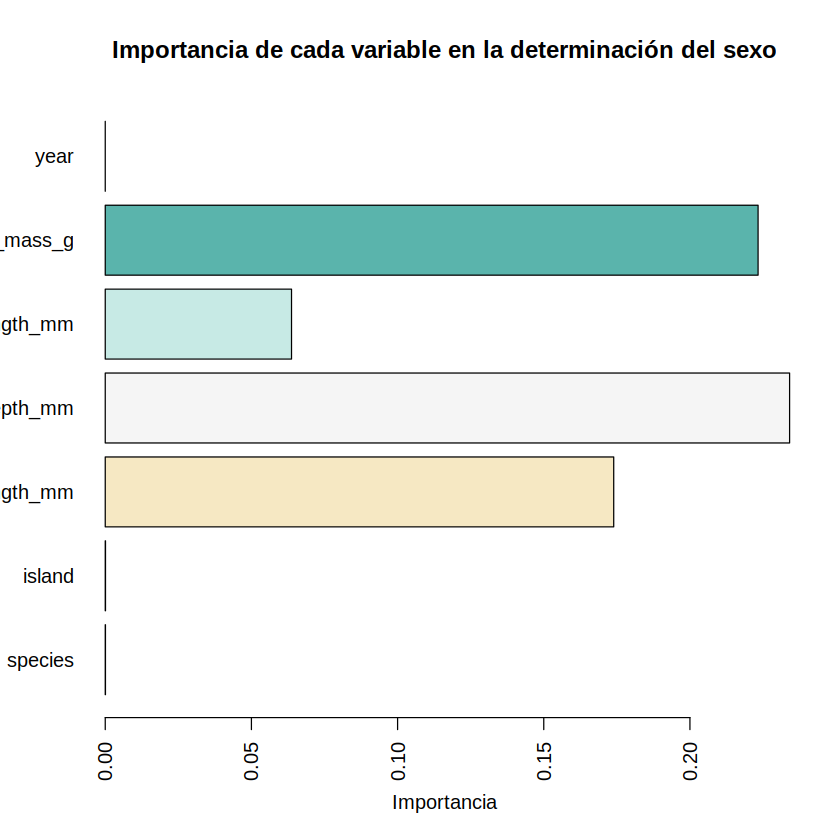

In [117]:
importance <- information.gain(sex~., df_penguins)
round(importance, 2)
barplot(importance[,1], main = 'Importancia de cada variable en la determinación del sexo',
       xlab = 'Importancia', names = rownames(importance), col = brewer.pal(7, 'BrBG'), 
       horiz = TRUE, las = 2)

#Se observa que year, island, species no tienen influencia en la determinacion del sexo

### Information Gain
### https://www.r-bloggers.com/2020/02/how-is-information-gain-calculated/#:~:text=What%20is%20information%20gain%3F,each%20step%20in%20the%20tree.

In [118]:
# Utilizamos el dataset con los casos con NA values eliminados
df <- na.omit(df_penguins)
df <- as.data.frame(df)
rownames(df) <- paste0(paste0(paste0(rownames(df), substr(df$species,1,1)), substr(df$island,1,1)), substr(df$sex,1,1))
head(df)

#Preparando los datos para GLM, factor sex: female = 0, male = 1
#Escalar los datos


df.sc <- data.frame(scale(df[, 3:6]))
df.sc$sex <- as.factor(ifelse(df$sex == 'female', 0, 1))
head(df.sc)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
1ATm,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2ATf,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3ATf,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4ATf,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
5ATm,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
6ATf,Adelie,Torgersen,38.9,17.8,181,3625,female,2007


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1ATm,-0.8946955,0.7795590,-1.4246077,-0.5676206,1
2ATf,-0.8215515,0.1194043,-1.0678666,-0.5055254,0
3ATf,-0.6752636,0.4240910,-0.4257325,-1.1885721,0
4ATf,-1.3335592,1.0842457,-0.5684290,-0.9401915,0
5ATm,-0.8581235,1.7444004,-0.7824736,-0.6918109,1
6ATf,-0.9312674,0.3225288,-1.4246077,-0.7228585,0


In [119]:
set.seed(33)
index <- createDataPartition(df.sc$sex, p = 0.75, list = FALSE)
train_data <- df.sc[index, ]
test_data <- df.sc[-index, ]
sprintf("The trainining set contains %d rows", nrow(train_data))
sprintf("The test set contains %d rows", nrow(test_data))

[1] "The trainining set contains 250 rows"

[1] "The test set contains 83 rows"

In [120]:
table(train_data$sex)
#El grupo de training esta balanceado



  0   1 
124 126 

Modelos logit con R
<a href='https://www.institutomora.edu.mx/testU/SitePages/martinpaladino/modelos_logit_con_R.html'>Enlace</a>

In [121]:
 # Logistic model
logistic_model <- glm(sex ~ ., data = train_data, family = 'binomial')
#summary(logistic_model)
predict_reg <- predict(logistic_model, test_data, type = 'response')
predict_reg <- ifelse(predict_reg >0.5, 1, 0)

# Evaluating model accuracy
# using confusion matrix
table(test_data$sex, predict_reg)


test_data$Prediccion <- predict_reg
test_data$Comp <- test_data$Prediccion == test_data$sex
sprintf("Resultado con todas las variables es %f", round(mean(test_data$Comp), 3) )

   predict_reg
     0  1
  0 35  6
  1  2 40

[1] "Resultado con todas las variables es 0.904000"

In [122]:
# ROC-AUC Curve
ROCPred <- prediction(predict_reg, test_data$sex) 
ROCPer <- performance(ROCPred, measure = "tpr", 
                             x.measure = "fpr") # True positive rate (tpr) y False positive rate(fpr)

auc <- performance(ROCPred, measure = "auc")
auc <- auc@y.values[[1]]
auc

[1] 0.9030197

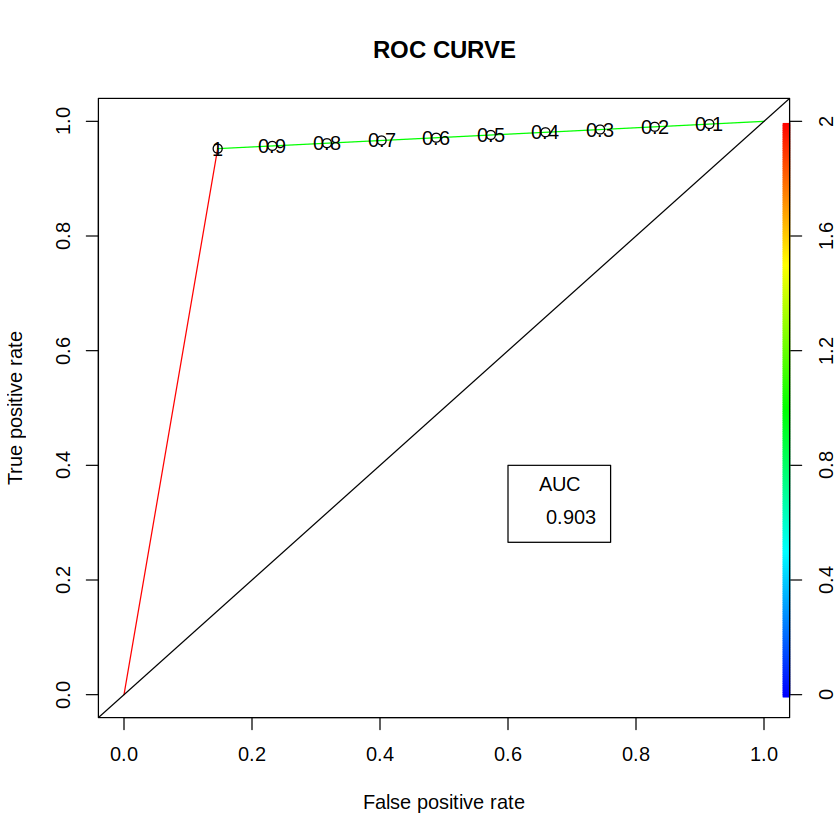

In [123]:
# Plotting curve

#plot(ROCPer)
plot(ROCPer, colorize = TRUE, 
     print.cutoffs.at = seq(0.1, by = 0.1), 
     main = "ROC CURVE")
abline(a = 0, b = 1)
auc <- round(auc, 4)
legend(.6, .4, auc, title = "AUC", cex = 1)

In [50]:
df_NA <- df_penguins[!complete.cases(df_penguins), ]
df_NA <- data.frame(df_NA[c(2:10), ])
rownames(df_NA) <- paste0('NA', rownames(df_NA))
df_NA.sc <- data.frame(scale(df_NA[3:6]))
df_NA.sc

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
,<dbl>,<dbl>,<dbl>,<dbl>
NA1,-1.5538764,0.6509262,-0.3639707,-0.7809657
NA2,0.1510713,1.5900486,-0.5459561,0.3598166
NA3,-0.7553566,0.2037250,-0.7886033,-1.0385617
NA4,-0.7553566,0.2931652,-1.1525740,-0.4497708
NA5,-0.8201014,1.0086871,-1.2132358,-1.5169543
NA6,0.6906117,-1.0484383,1.0312504,0.1390201
NA7,1.0574992,-1.0037182,0.9099269,0.9486075
NA8,1.2948970,-1.2720389,1.0312504,1.0590058
NA9,0.6906117,-0.4223567,1.0919122,1.2798024


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
NA1,Adelie,Torgersen,34.1,18.1,193,3475,NA,2007
NA2,Adelie,Torgersen,42.0,20.2,190,4250,NA,2007
NA3,Adelie,Torgersen,37.8,17.1,186,3300,NA,2007
NA4,Adelie,Torgersen,37.8,17.3,180,3700,NA,2007
NA5,Adelie,Dream,37.5,18.9,179,2975,NA,2007
NA6,Gentoo,Biscoe,44.5,14.3,216,4100,NA,2007
NA7,Gentoo,Biscoe,46.2,14.4,214,4650,NA,2008
NA8,Gentoo,Biscoe,47.3,13.8,216,4725,NA,2009
NA9,Gentoo,Biscoe,44.5,15.7,217,4875,NA,2009


In [44]:
predict_NA <- predict(logistic_model, df_NA.sc, type = 'response')
predict_NA <- ifelse(predict_NA >0.5, 1, 0)
predict_NA

NA1 NA2 NA3 NA4 NA5 NA6 NA7 NA8 NA9 
  0   1   0   0   0   0   1   0   1

In [59]:
df_NA$sex <- predict_NA
df_NA$sex <-  factor(ifelse(df_NA$sex == 0, 'female', 'male'))
df_NA$body_mass_g

[1] 3475 4250 3300 3700 2975 4100 4650 4725 4875

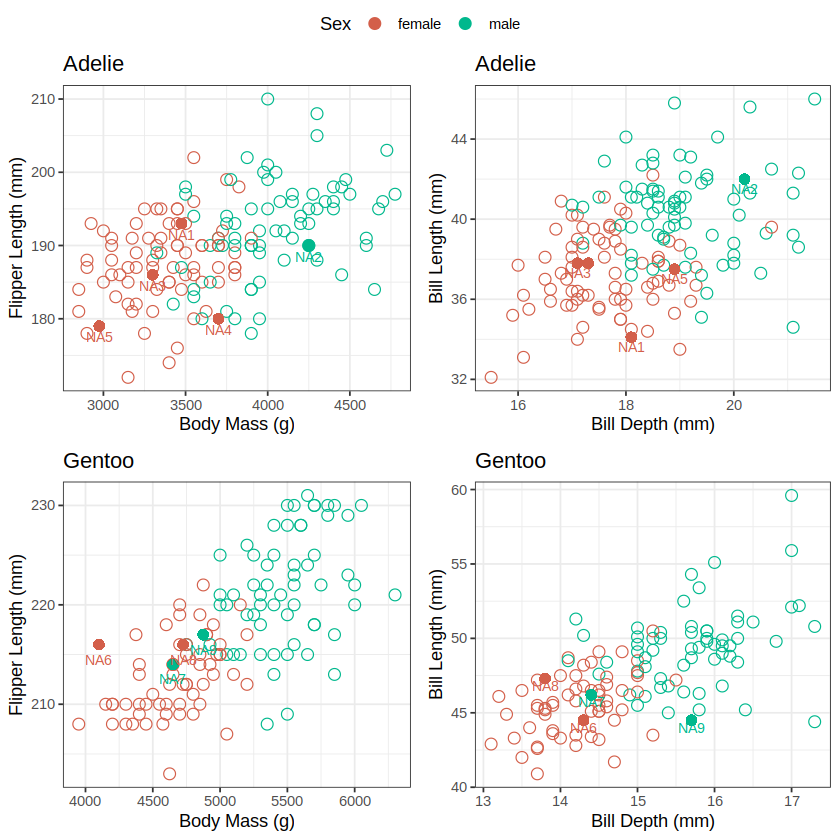

In [111]:
p1 <- ggplot() +
        geom_point(data = df[df$species == 'Adelie', ], 
                   aes(y = flipper_length_mm, x = body_mass_g, color = sex, shape =sex), 
                        size = 3, pch = 21) +
        geom_point(data = df_NA[df_NA$species == 'Adelie', ], 
                   aes(y = flipper_length_mm, x = body_mass_g, color = sex, shape =sex), 
                        size = 3, pch = 16) + 
        geom_text(data = df_NA[df_NA$species == 'Adelie', ], 
                  aes(y = flipper_length_mm, x = body_mass_g, 
                      label = rownames(df_NA[df_NA$species == 'Adelie', ]), 
                      color = sex), 
                  size = 3, nudge_y = -1.5) +
        scale_color_manual(values = sex_color) +  
        labs(title = 'Adelie', 
                y = "Flipper Length (mm)",
                x = "Body Mass (g)",
                color = "Sex",
                shape = "Sex") +
        theme_bw() +
        theme(legend.position = c(0.85, 0.2))

p2 <- ggplot() +
        geom_point(data = df[df$species == 'Adelie', ], 
                   aes(y = bill_length_mm, x = bill_depth_mm, color = sex, shape =sex), 
                        size = 3, pch = 21) +
        geom_point(data = df_NA[df_NA$species == 'Adelie', ], 
                   aes(y = bill_length_mm, x = bill_depth_mm, color = sex, shape =sex), 
                        size = 3, pch = 16) + 
        geom_text(data = df_NA[df_NA$species == 'Adelie', ], 
                  aes(y = bill_length_mm, x = bill_depth_mm, 
                      label = rownames(df_NA[df_NA$species == 'Adelie', ]), 
                      color = sex), 
                  size = 3, nudge_y = -0.5, check_overlap = TRUE) +
        scale_color_manual(values = sex_color) +  
        labs(title = 'Adelie', 
                y = "Bill Length (mm)",
                x = "Bill Depth (mm)",
                color = "Sex",
                shape = "Sex") +
        theme_bw() +
        theme(legend.position = c(0.85, 0.2))

p3 <- ggplot() +
        geom_point(data = df[df$species == 'Gentoo', ], 
                   aes(y = flipper_length_mm, x = body_mass_g, color = sex, shape =sex), 
                        size = 3, pch = 21) +
        geom_point(data = df_NA[df_NA$species == 'Gentoo', ], 
                   aes(y = flipper_length_mm, x = body_mass_g, color = sex, shape =sex), 
                        size = 3, pch = 16) + 
        geom_text(data = df_NA[df_NA$species == 'Gentoo', ], 
                  aes(y = flipper_length_mm, x = body_mass_g, 
                      label = rownames(df_NA[df_NA$species == 'Gentoo', ]), 
                      color = sex), 
                  size = 3, nudge_y = -1.5) +
        scale_color_manual(values = sex_color) +  
        labs(title = 'Gentoo', 
                y = "Flipper Length (mm)",
                x = "Body Mass (g)",
                color = "Sex",
                shape = "Sex") +
        theme_bw() +
        theme(legend.position = c(0.85, 0.2))

p4 <- ggplot() +
        geom_point(data = df[df$species == 'Gentoo', ], 
                   aes(y = bill_length_mm, x = bill_depth_mm, color = sex, shape =sex), 
                        size = 3, pch = 21) +
        geom_point(data = df_NA[df_NA$species == 'Gentoo', ], 
                   aes(y = bill_length_mm, x = bill_depth_mm, color = sex, shape =sex), 
                        size = 3, pch = 16) + 
        geom_text(data = df_NA[df_NA$species == 'Gentoo', ], 
                  aes(y = bill_length_mm, x = bill_depth_mm, 
                      label = rownames(df_NA[df_NA$species == 'Gentoo', ]), 
                      color = sex), 
                  size = 3, nudge_y = -0.5, check_overlap = TRUE) +
        scale_color_manual(values = sex_color) +  
        labs(title = 'Gentoo', 
                y = "Bill Length (mm)",
                x = "Bill Depth (mm)",
                color = "Sex",
                shape = "Sex") +
        theme_bw() +
        theme(legend.position = c(0.85, 0.2))

ggarrange(p1, p2, p3, p4,
          ncol = 2, nrow = 2, common.legend = TRUE, legend="top")